# Практика: Метод опорных векторов (SVM)

## Что вы сделаете

В этом ноутбуке вы:

1. Загрузите датасет Breast Cancer и проведёте базовый EDA;
2. Обучите **LinearSVC** — быстрый линейный SVM;
3. Исследуете влияние **масштабирования признаков** на качество;
4. Подберёте гиперпараметры (**C**, **kernel**, **gamma**) через `GridSearchCV`;
5. Визуализируете **границу решений** на двух признаках;
6. Проанализируете **ошибки** модели и опорные векторы;
7. Сравните линейный и RBF SVM.

**Датасет:** [Breast Cancer Wisconsin](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) — бинарная классификация (злокачественная / доброкачественная опухоль), 569 примеров, 30 числовых признаков.

---
**Как работать:** ячейки с `# YOUR CODE HERE` нужно заполнить самостоятельно. Там же указаны подсказки и ожидаемые результаты.

## Коротко о теории

### Разделяющая гиперплоскость и margin

SVM ищет гиперплоскость $\mathbf{w}^\top \mathbf{x} + b = 0$, максимизирующую зазор (margin):

$$\text{margin} = \frac{2}{\|\mathbf{w}\|}$$

Это эквивалентно задаче:

$$\min_{\mathbf{w},b}\; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i \quad \text{при} \quad y_i(\mathbf{w}^\top\mathbf{x}_i + b) \geq 1 - \xi_i$$

### Ядровой трюк

RBF ядро: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma\|\mathbf{x}_i - \mathbf{x}_j\|^2)$ — позволяет строить нелинейные границы без явного перехода в высокомерное пространство.

### Ключевые параметры

| Параметр | Влияние |
|---|---|
| `C` большой | Узкий margin, мало ошибок на train, риск переобучения |
| `C` малый | Широкий margin, допускает ошибки, лучше обобщение |
| `gamma` большой | Сложная граница, переобучение |
| `gamma` малый | Гладкая граница, недообучение |

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Импорты выполнены успешно!')

Импорты выполнены успешно!


In [62]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Размер датасета:', X.shape)
print('Классы:', data.target_names)
print('Распределение классов:')
print(y.value_counts())

display(X.head())

Размер датасета: (569, 30)
Классы: ['malignant' 'benign']
Распределение классов:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Пропуски по признакам:


np.int64(0)


Базовая статистика первых 5 признаков:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163


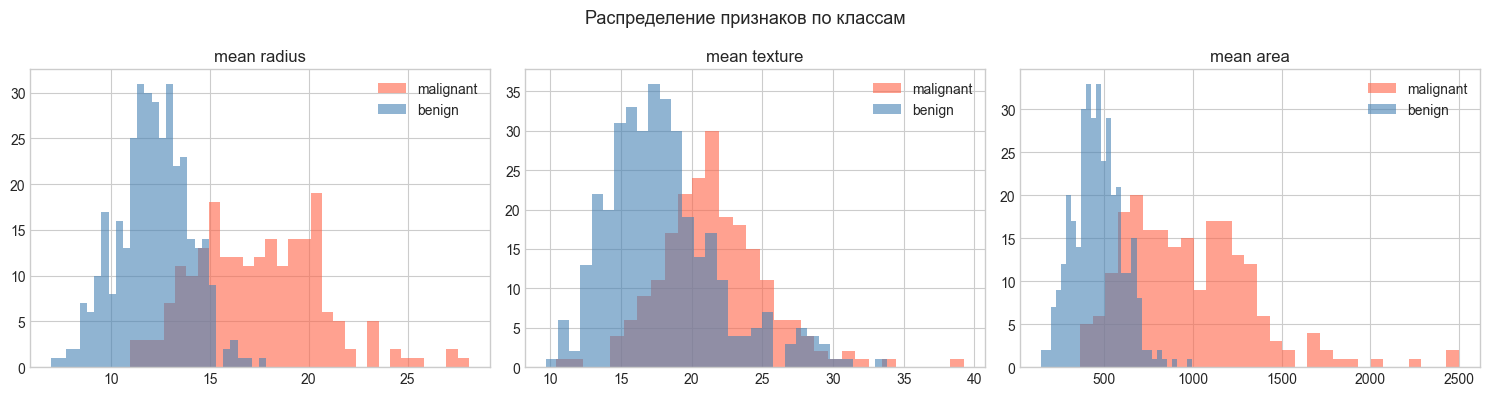

In [63]:
# EDA: базовая статистика и распределения
print('Пропуски по признакам:')
display(X.isna().sum().sum())

print('\nБазовая статистика первых 5 признаков:')
display(X.iloc[:, :5].describe().T.round(3))

# Распределение нескольких признаков по классам
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features_to_plot = ['mean radius', 'mean texture', 'mean area']

for ax, feat in zip(axes, features_to_plot):
    for cls, label, color in [(0, 'malignant', 'tomato'), (1, 'benign', 'steelblue')]:
        ax.hist(X.loc[y == cls, feat], bins=30, alpha=0.6, label=label, color=color)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Распределение признаков по классам', fontsize=13)
plt.tight_layout()
plt.show()

## Шаг 1. Разделение данных

Разбейте выборку на train и test в соотношении 80/20, зафиксировав `random_state=42`.

Убедитесь, что стратификация сохраняет баланс классов: используйте `stratify=y`.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Баланс классов в train:', y_train.value_counts().to_dict())
print('Баланс классов в test:', y_test.value_counts().to_dict())

Train shape: (426, 30)
Test shape: (143, 30)
Баланс классов в train: {1: 268, 0: 158}
Баланс классов в test: {1: 89, 0: 54}


## Шаг 2. SVM без масштабирования — что будет?

Сначала обучим SVC с RBF ядром **без нормализации** и зафиксируем качество. Потом сравним с нормализованным вариантом.

Используйте `SVC(kernel='rbf', C=1.0, random_state=42)`.

In [65]:
model = SVC(kernel='rbf', C=1.0, random_state=42)
model.fit(X_train, y_train)
y_pred_no = model.predict(X_test)

svm_no_scale = {
    "accuracy": accuracy_score(y_test, y_pred_no),
    "f1": f1_score(y_test, y_pred_no, average='macro', zero_division=0),
}

print(f"Accuracy без масштабирования: {svm_no_scale['accuracy']:.3f}")
print(f"F1 без масштабирования: {svm_no_scale['f1']:.3f}")

Accuracy без масштабирования: 0.951
F1 без масштабирования: 0.947


## Шаг 3. SVM с масштабированием через Pipeline

Теперь постройте Pipeline:
```
StandardScaler → SVC(kernel='rbf', C=1.0, random_state=42)
```

Сравните результат с шагом 2. Ожидаемое улучшение: заметный прирост accuracy и F1.

In [66]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, random_state=42))
])

pipe.fit(X_train, y_train)

y_pred_scale = pipe.predict(X_test)

svm_scale = {
    "accuracy": accuracy_score(y_test, y_pred_scale),
    "f1": f1_score(y_test, y_pred_scale, average='macro', zero_division=0),
}

print(f"Accuracy С масштабированием: {svm_scale['accuracy']:.3f}")
print(f"F1 С масштабированием: {svm_scale['f1']:.3f}")
print('\nКлассификационный отчёт:')
print(classification_report(y_test, y_pred_scale))

Accuracy С масштабированием: 0.972
F1 С масштабированием: 0.970

Классификационный отчёт:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        54
           1       0.98      0.98      0.98        89

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



## Шаг 4. Подбор гиперпараметров через GridSearchCV

Используйте `GridSearchCV` для перебора следующей сетки параметров:

```python
param_grid = {
    'svm__C':      [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 0.01, 0.1],
}
```

Параметры поиска: `cv=5`, `scoring='f1'`.

**Важно:** используйте тот же Pipeline со скейлером, чтобы избежать data leakage!

In [67]:
import time

param_grid = {
    'svm__C':      [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 0.01, 0.1],
}

pip_grcv = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, random_state=42))
])

start_time_grid  = time.time()
search = GridSearchCV(pip_grcv, param_grid, cv=5, scoring='f1')

search.fit(X_train, y_train)
time_grid  = time.time() - start_time_grid

print('Лучшие параметры:', search.best_params_)
print(f"CV F1 (best): {search.best_score_:.3f}")

Лучшие параметры: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
CV F1 (best): 0.982


In [68]:
best_model = search.best_estimator_

y_pred_best = best_model.predict(X_test)

print(f"Test accuracy (best): {accuracy_score(y_test, y_pred_scale):.3f}")
print(f"Test F1 (best): {f1_score(y_test, y_pred_scale, average='macro', zero_division=0):.3f}")
print(classification_report(y_test, y_pred_best,
                             target_names=data.target_names))

grid_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_scale),
    "f1": f1_score(y_test, y_pred_scale, average='macro', zero_division=0)
}

Test accuracy (best): 0.972
Test F1 (best): 0.970
              precision    recall  f1-score   support

   malignant       0.98      0.96      0.97        54
      benign       0.98      0.99      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



## Шаг 5. Confusion Matrix

Визуализируйте матрицу ошибок для лучшей модели.

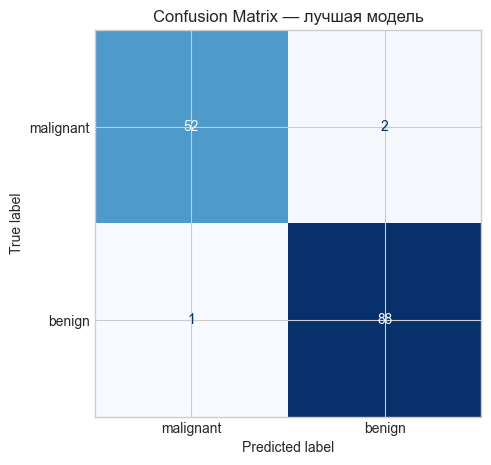

In [69]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_best,  
    display_labels=data.target_names, #названия классов для отображения
    ax=ax,
    colorbar=False,
    cmap='Blues'
)
ax.set_title('Confusion Matrix — лучшая модель')
plt.tight_layout()
plt.show()

## Шаг 6. Граница решений на двух признаках

Для визуализации возьмём два признака: `'mean radius'` и `'mean texture'`.

Обучите SVM с RBF ядром и лучшими найденными `C` и `gamma` на этих двух признаках, затем визуализируйте границу решений.

Ниже дана вспомогательная функция — вам нужно её вызвать.

In [70]:
def plot_decision_boundary(model, X_2d, y, title='Граница решений SVM'):
    h = 0.05
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25,
                 cmap=mcolors.ListedColormap(['tomato', 'steelblue']))
    plt.contour(xx, yy, Z, colors='k', linewidths=0.8)
    colors = ['tomato' if c == 0 else 'steelblue' for c in y]
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, edgecolors='k', s=40, alpha=0.8)
    plt.xlabel('mean radius (scaled)')
    plt.ylabel('mean texture (scaled)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

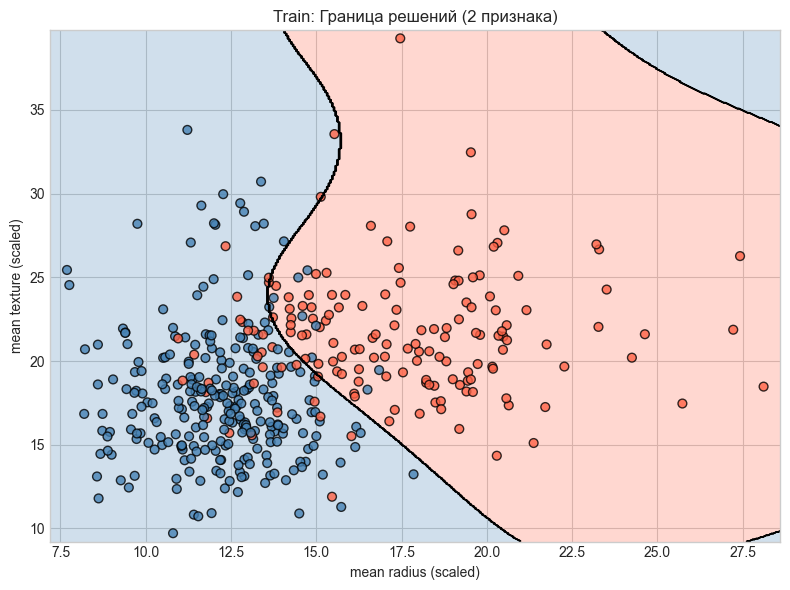

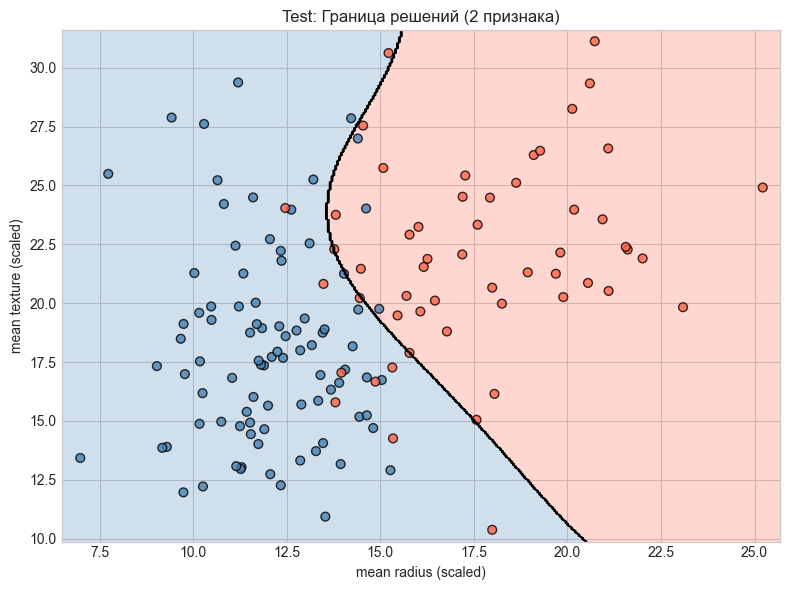

In [71]:
feat1, feat2 = 'mean radius', 'mean texture'

X_train_2d = X_train[[feat1, feat2]].values
X_test_2d  = X_test[[feat1, feat2]].values

pipe_2d = Pipeline([
    ('scaler', StandardScaler()),
    ('best_svc', SVC(kernel='rbf', C=search.best_params_['svm__C'], gamma=search.best_params_['svm__gamma']))
])

pipe_2d.fit(X_train_2d, y_train)


plot_decision_boundary(pipe_2d, X_train_2d, y_train.values,
                       title='Train: Граница решений (2 признака)')
plot_decision_boundary(pipe_2d, X_test_2d, y_test.values,
                       title='Test: Граница решений (2 признака)')

## Шаг 7. Анализ ошибок

Найдите примеры, на которых лучшая модель ошиблась. Посмотрите, есть ли у них что-то общее.

1. Выберите неверно классифицированные примеры из тестовой выборки.
2. Выведите их признаки (первые 5 признаков для читаемости).
3. Ответьте в markdown-ячейке: какие классы ошибочно смешиваются?

In [72]:
errors_idx = np.where(y_pred_best != y_test)[0]

print(f'Число ошибочных предсказаний: {len(errors_idx)}')

errors_df = X_test.iloc[errors_idx, :5].copy()
errors_df['true_label'] = y_test.values[errors_idx]
errors_df['pred_label'] = y_pred_best[errors_idx]

display(errors_df)

Число ошибочных предсказаний: 3


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,true_label,pred_label
73,13.800,15.79,90.43,584.1,0.1007,0,1
255,13.960,17.05,91.43,602.4,0.1096,0,1
68,9.029,17.33,58.79,250.5,0.1066,1,0


### Ваш анализ ошибок

**(Ответьте здесь):**
- Сколько ошибок типа False Positive (предсказали «доброкачественная», а на самом деле «злокачественная»)?
- Сколько ошибок типа False Negative?
- Какой тип ошибки более критичен в медицинской задаче? Почему?

-----
1. 1 ошибки типа FP
2. 2 ошибка типа FN
3. Более критична ошибка типа FN, так как FN результат означает, что пациент с злокачественной опухолью не получит своевременного лечения, что может привести к прогрессированию заболевания и летальному исходу. FP результат, хотя и вызывает стресс и дополнительные обследования, не несёт прямой угрозы жизни, лучше перестраховаться. Поэтому в медицинской задаче приоритет отдаётся минимизации FN.
-----

## Шаг 8. Линейный vs RBF SVM: сравнение

Сравните два финальных пайплайна:
- `LinearSVC` с подобранным `C`;
- `SVC(kernel='rbf')` с лучшими параметрами.

Используйте **5-fold cross-validation** на тренировочной выборке (метрика `f1`).

In [73]:
pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C=search.best_params_['svm__C'], max_iter=5000, random_state=42))
])

pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=search.best_params_['svm__C'], gamma=search.best_params_['svm__gamma']))
])

for name, model in [('LinearSVC', pipe_linear), ('RBF SVC', pipe_rbf)]:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    print(f'{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}')

LinearSVC: F1 = 0.9833 ± 0.0109
RBF SVC: F1 = 0.9492 ± 0.0066


## Шаг 9. Сводная таблица результатов

Соберите итоговую таблицу, сравнивающую все модели:
- SVM без масштабирования (шаг 2)
- SVM со масштабированием (шаг 3)
- Лучшая модель после GridSearch (шаг 4)

In [74]:
def get_metrics(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_no),   # no_scale
    get_metrics(y_test, y_pred_scale),   # with_scale
    get_metrics(y_test, y_pred_best),   # best_grid
], index=['no_scale', 'with_scale', 'best_grid'])

display(results.round(4))

,accuracy,precision,recall,f1
no_scale,0.951,0.9362,0.9888,0.9617
with_scale,0.972,0.9775,0.9775,0.9775
best_grid,0.979,0.9778,0.9888,0.9832


## Шаг 10. Доп задания


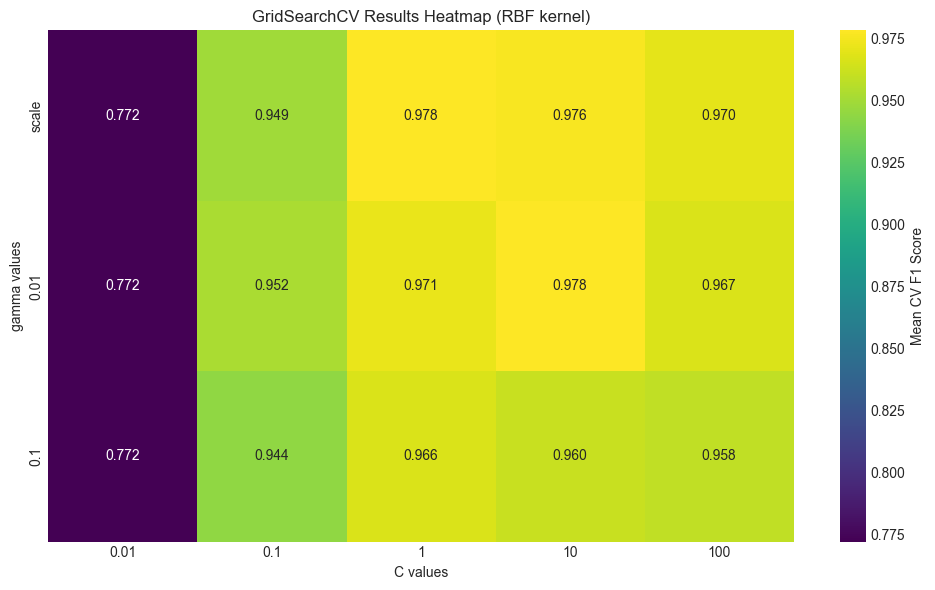

In [75]:
import seaborn as sns

cv_results = search.cv_results_
C_values = search.param_grid['svm__C']
gamma_values = [g for g in search.param_grid['svm__gamma'] if g != 'scale']
gamma_values = ['scale'] + gamma_values

scores_matrix = np.zeros((len(gamma_values), len(C_values)))
for i, gamma in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        for idx, params in enumerate(cv_results['params']):
            if params['svm__C'] == C and params['svm__gamma'] == gamma and params['svm__kernel'] == 'rbf':
                scores_matrix[i, j] = cv_results['mean_test_score'][idx]
                break

plt.figure(figsize=(10, 6))
sns.heatmap(scores_matrix, 
            xticklabels=C_values, 
            yticklabels=gamma_values,
            annot=True, 
            fmt='.3f', 
            cmap='viridis',
            cbar_kws={'label': 'Mean CV F1 Score'})
plt.xlabel('C values')
plt.ylabel('gamma values')
plt.title('GridSearchCV Results Heatmap (RBF kernel)')
plt.tight_layout()
plt.show()

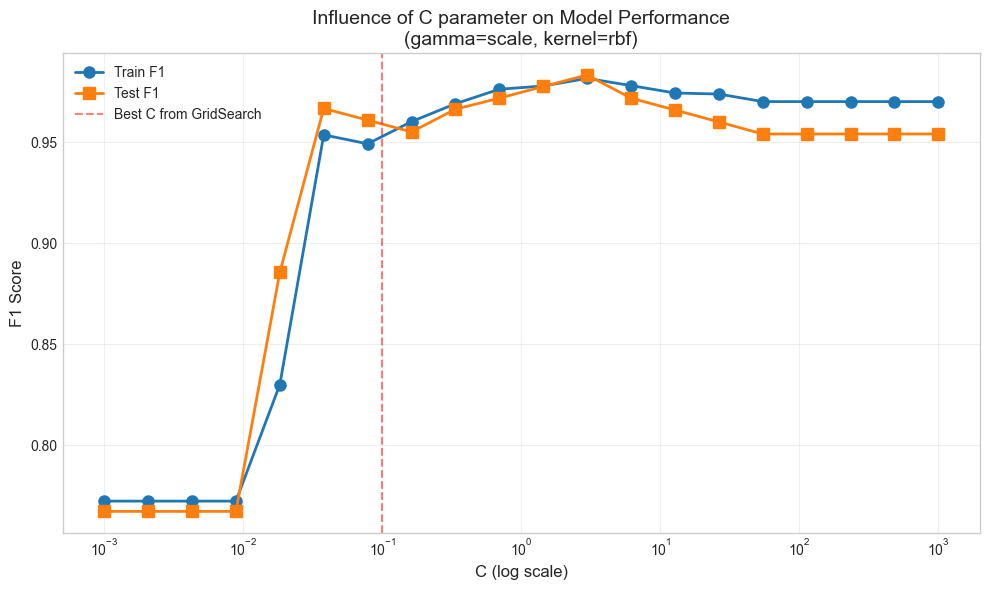

In [76]:
gamma_fixed = 'scale'
kernel_fixed = 'rbf'

C_values_range = np.logspace(-3, 3, 20)
train_scores = []
test_scores = []    

for C in C_values_range:
    pipe_temp = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel=kernel_fixed, C=C, gamma=gamma_fixed))
    ])
    
    cv_scores = cross_val_score(pipe_temp, X_train, y_train, cv=5, scoring='f1')
    train_scores.append(cv_scores.mean())
    
    pipe_temp.fit(X_train, y_train)
    y_pred_temp = pipe_temp.predict(X_test)
    test_scores.append(f1_score(y_test, y_pred_temp))

plt.figure(figsize=(10, 6))
plt.semilogx(C_values_range, train_scores, 'o-', label='Train F1', linewidth=2, markersize=8)
plt.semilogx(C_values_range, test_scores, 's-', label='Test F1', linewidth=2, markersize=8)
plt.axvline(x=0.1, color='r', linestyle='--', alpha=0.5, label='Best C from GridSearch')
plt.xlabel('C (log scale)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Influence of C parameter on Model Performance\n(gamma=scale, kernel=rbf)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
best_model_original = best_model

best_params_clean = {k.replace('svm__', ''): v for k, v in search.best_params_.items()}

best_model_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(**best_params_clean, class_weight='balanced'))
])
best_model_balanced.fit(X_train, y_train)

y_pred_original = best_model_original.predict(X_test)
y_pred_balanced = best_model_balanced.predict(X_test)

recall_original_class0 = recall_score(y_test, y_pred_original, pos_label=0)
recall_balanced_class0 = recall_score(y_test, y_pred_balanced, pos_label=0)

print(f"\nRecall для класса 'malignant' (0):")
print(f"Без class_weight: {recall_original_class0:.4f}")
print(f"С class_weight='balanced': {recall_balanced_class0:.4f}")
print(f"Улучшение: {recall_balanced_class0 - recall_original_class0:+.4f}")

print("\nСравнение метрик для класса MALIGNANT (злокачественная):")
print(classification_report(y_test, y_pred_original, target_names=data.target_names, digits=4))
print("\nС class_weight='balanced':")
print(classification_report(y_test, y_pred_balanced, target_names=data.target_names, digits=4))



Recall для класса 'malignant' (0):
Без class_weight: 0.9630
С class_weight='balanced': 0.9815
Улучшение: +0.0185

Сравнение метрик для класса MALIGNANT (злокачественная):
              precision    recall  f1-score   support

   malignant     0.9811    0.9630    0.9720        54
      benign     0.9778    0.9888    0.9832        89

    accuracy                         0.9790       143
   macro avg     0.9795    0.9759    0.9776       143
weighted avg     0.9790    0.9790    0.9790       143


С class_weight='balanced':
              precision    recall  f1-score   support

   malignant     0.9636    0.9815    0.9725        54
      benign     0.9886    0.9775    0.9831        89

    accuracy                         0.9790       143
   macro avg     0.9761    0.9795    0.9778       143
weighted avg     0.9792    0.9790    0.9791       143




1. FN для malignant = пропуск рака
   - Пациент не получит своевременное лечение
   - Может привести к летальному исходу
   
2. `class_weight='balanced'` автоматически увеличивает
   вес меньшинства классов, заставляя модель быть
   более внимательной к редким случаям
   
3. В датасете:
   - benign (доброкачественная): 357 примеров
   - malignant (злокачественная): 212 примеров
   
4. Лучше иметь больше FP (ложная тревога),
   чем FN (пропуск болезни)!
-----

In [78]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
import time

param_dist = {
    'svm__C': loguniform(1e-3, 1e3),
    'svm__gamma': loguniform(1e-4, 1e1),
    'svm__kernel': ['linear', 'rbf'],
}

pipe_random = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

print("\nЗапуск RandomizedSearchCV...")
start_time_random = time.time()
random_search = RandomizedSearchCV(
    pipe_random, 
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
time_random = time.time() - start_time_random

print(f"RandomizedSearchCV:")
print(f"Время выполнения: {time_random:.2f} сек")
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"CV F1 score: {random_search.best_score_:.4f}")

print(f"\nGridSearchCV:")
print(f"Время выполнения: {time_grid:.2f} сек")
print(f"Лучшие параметры: {search.best_params_}")
print(f"CV F1 score: {search.best_score_:.4f}")


y_pred_random = random_search.predict(X_test)
random_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_random),
    "f1": f1_score(y_test, y_pred_random)
}

comparison = pd.DataFrame([grid_metrics, random_metrics], index=["grid_model", "random_model"])
display(comparison.round(4))


Запуск RandomizedSearchCV...
RandomizedSearchCV:
Время выполнения: 0.13 сек
Лучшие параметры: {'svm__C': np.float64(9.443515687962675), 'svm__gamma': np.float64(0.003618723330959626), 'svm__kernel': 'rbf'}
CV F1 score: 0.9815

GridSearchCV:
Время выполнения: 0.45 сек
Лучшие параметры: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
CV F1 score: 0.9815


,accuracy,f1
grid_model,0.972,0.9702
random_model,0.986,0.9889


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. Почему SVM необходимо масштабировать признаки? Что конкретно ломается без нормализации?
2. Что произойдёт с границей решений, если сильно увеличить параметр `C`? А если уменьшить?
3. Что такое опорные векторы и почему предсказание зависит только от них?
4. В каких случаях стоит выбрать линейное ядро вместо RBF?
5. Почему нельзя обучать `StandardScaler` на всей выборке (train + test) перед кросс-валидацией?

 
ㅤ


1.  SVM опирается на расстояние и скалярное произведение, если признаки будут измеряться в разных диапазонах, 
    зазор исказить в сторону признака с большим масштабом
2.  При слишком большом `C` сильно наказыват за ошибки, зазор узкий, граница сложная. При слишком 
    маленьком `C` модель допускает больше ошибок, зазор широкий, граница гладкая
3.  Это точки обучающей выборки, которые лежат ровно на границах зазора: $w^T x_i + b = ±1$, остальные точки 
    можно удалить из датасета, гиперплоскость от этого не поменяется
4.  Линейное ядро стоит выбрать, когда данных много, а признаков ещё больше, данные линейно разделимы, нужна   
    интерпретируемость
5.  Потому что это будет `data leakage`, метрика становится нереалистично хорошей, но на реальных 
    данных модель ломается
-----

## Дополнительные задания

### Задание A
Постройте тепловую карту результатов GridSearchCV: ось X — значения `C`, ось Y — значения `gamma`, цвет — CV F1. Используйте `search.cv_results_` и `plt.imshow` или `seaborn.heatmap`.

### Задание B
Исследуйте влияние `C` при фиксированном `gamma='scale'` и `kernel='rbf'`. Постройте график: ось X — `C` (лог-шкала), ось Y — train F1 и test F1 на одном графике. Где начинается переобучение?

### Задание C
Добавьте `class_weight='balanced'` к лучшей модели и сравните recall для класса `malignant` (класс 0). Улучшился ли он? Объясните, почему это важно в медицинской задаче.

### Задание D*
Используйте `RandomizedSearchCV` вместо `GridSearchCV` для более широкой сетки параметров:
```python
from scipy.stats import loguniform
param_dist = {
    'svm__C':     loguniform(1e-3, 1e3),
    'svm__gamma': loguniform(1e-4, 1e1),
    'svm__kernel': ['linear', 'rbf'],
}
```
Сравните время выполнения и итоговое качество с `GridSearchCV`.

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- Загрузка данных и EDA;
- Сравнение SVM с масштабированием и без;
- Подбор гиперпараметров через GridSearchCV;
- Визуализация границы решений на двух признаках;
- Анализ ошибок и confusion matrix;
- Сравнительная таблица линейного и RBF SVM.

**Ожидаемые результаты:**
- SVM без масштабирования: accuracy ≈ 0.63–0.80
- SVM со масштабированием (C=1, rbf): accuracy ≈ 0.97–0.98
- Лучшая модель после GridSearch: F1 ≥ 0.97